#Library imports

In [209]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from IPython.display import Image
from os import system

In [210]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

#Q1. Data Understanding & Exploration

In [242]:
#A.Read ‘TelcomCustomer-Churn_1.csv’ as a DataFrame and assign it to a variable
tc_data1 = pd.read_csv('/content/drive/MyDrive/DS_AIML/AIML_PGP_Code/4.Ensemble Techniques/Week16_Project Submission/TelcomCustomer-Churn_1.csv')
tc_data1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No


In [243]:
#B.Read ‘TelcomCustomer-Churn_2.csv’ as a DataFrame and assign it to a variable
tc_data2 = pd.read_csv('/content/drive/MyDrive/DS_AIML/AIML_PGP_Code/4.Ensemble Techniques/Week16_Project Submission/TelcomCustomer-Churn_2.csv')
tc_data2.head()

,customerID,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [244]:
#C.Merge both the DataFrames on key ‘customerID’ to form a single DataFrame
combined_df = tc_data1.merge(tc_data2, on='customerID')
combined_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [245]:
#D.Verify if all the columns are incorporated in the merged DataFrame by using simple comparison Operator in Python
print(tc_data1.shape, tc_data2.shape, combined_df.shape)
before_combine = set(tc_data1.columns.tolist()) | set(tc_data2.columns.tolist())
after_combine = set(combined_df.columns.tolist())
if before_combine == after_combine:
  print('All columns present before merge are also present after merge')
else:
  print('All columns present before merge are not present after merge')

(7043, 10) (7043, 12) (7043, 21)
All columns present before merge are also present after merge


#Q2. Data Cleaning & Analysis

In [246]:
#A.Impute missing/unexpected values in the DataFrame
print(combined_df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [247]:
#B.Make sure all the variables with continuous values are of ‘Float’ type
combined_df['tenure'] = combined_df['tenure'].astype(float)
print(len(combined_df[combined_df['TotalCharges'] == ' ']))
combined_df['TotalCharges'] = combined_df['TotalCharges'].str.replace(' ', '0').astype(float)

11


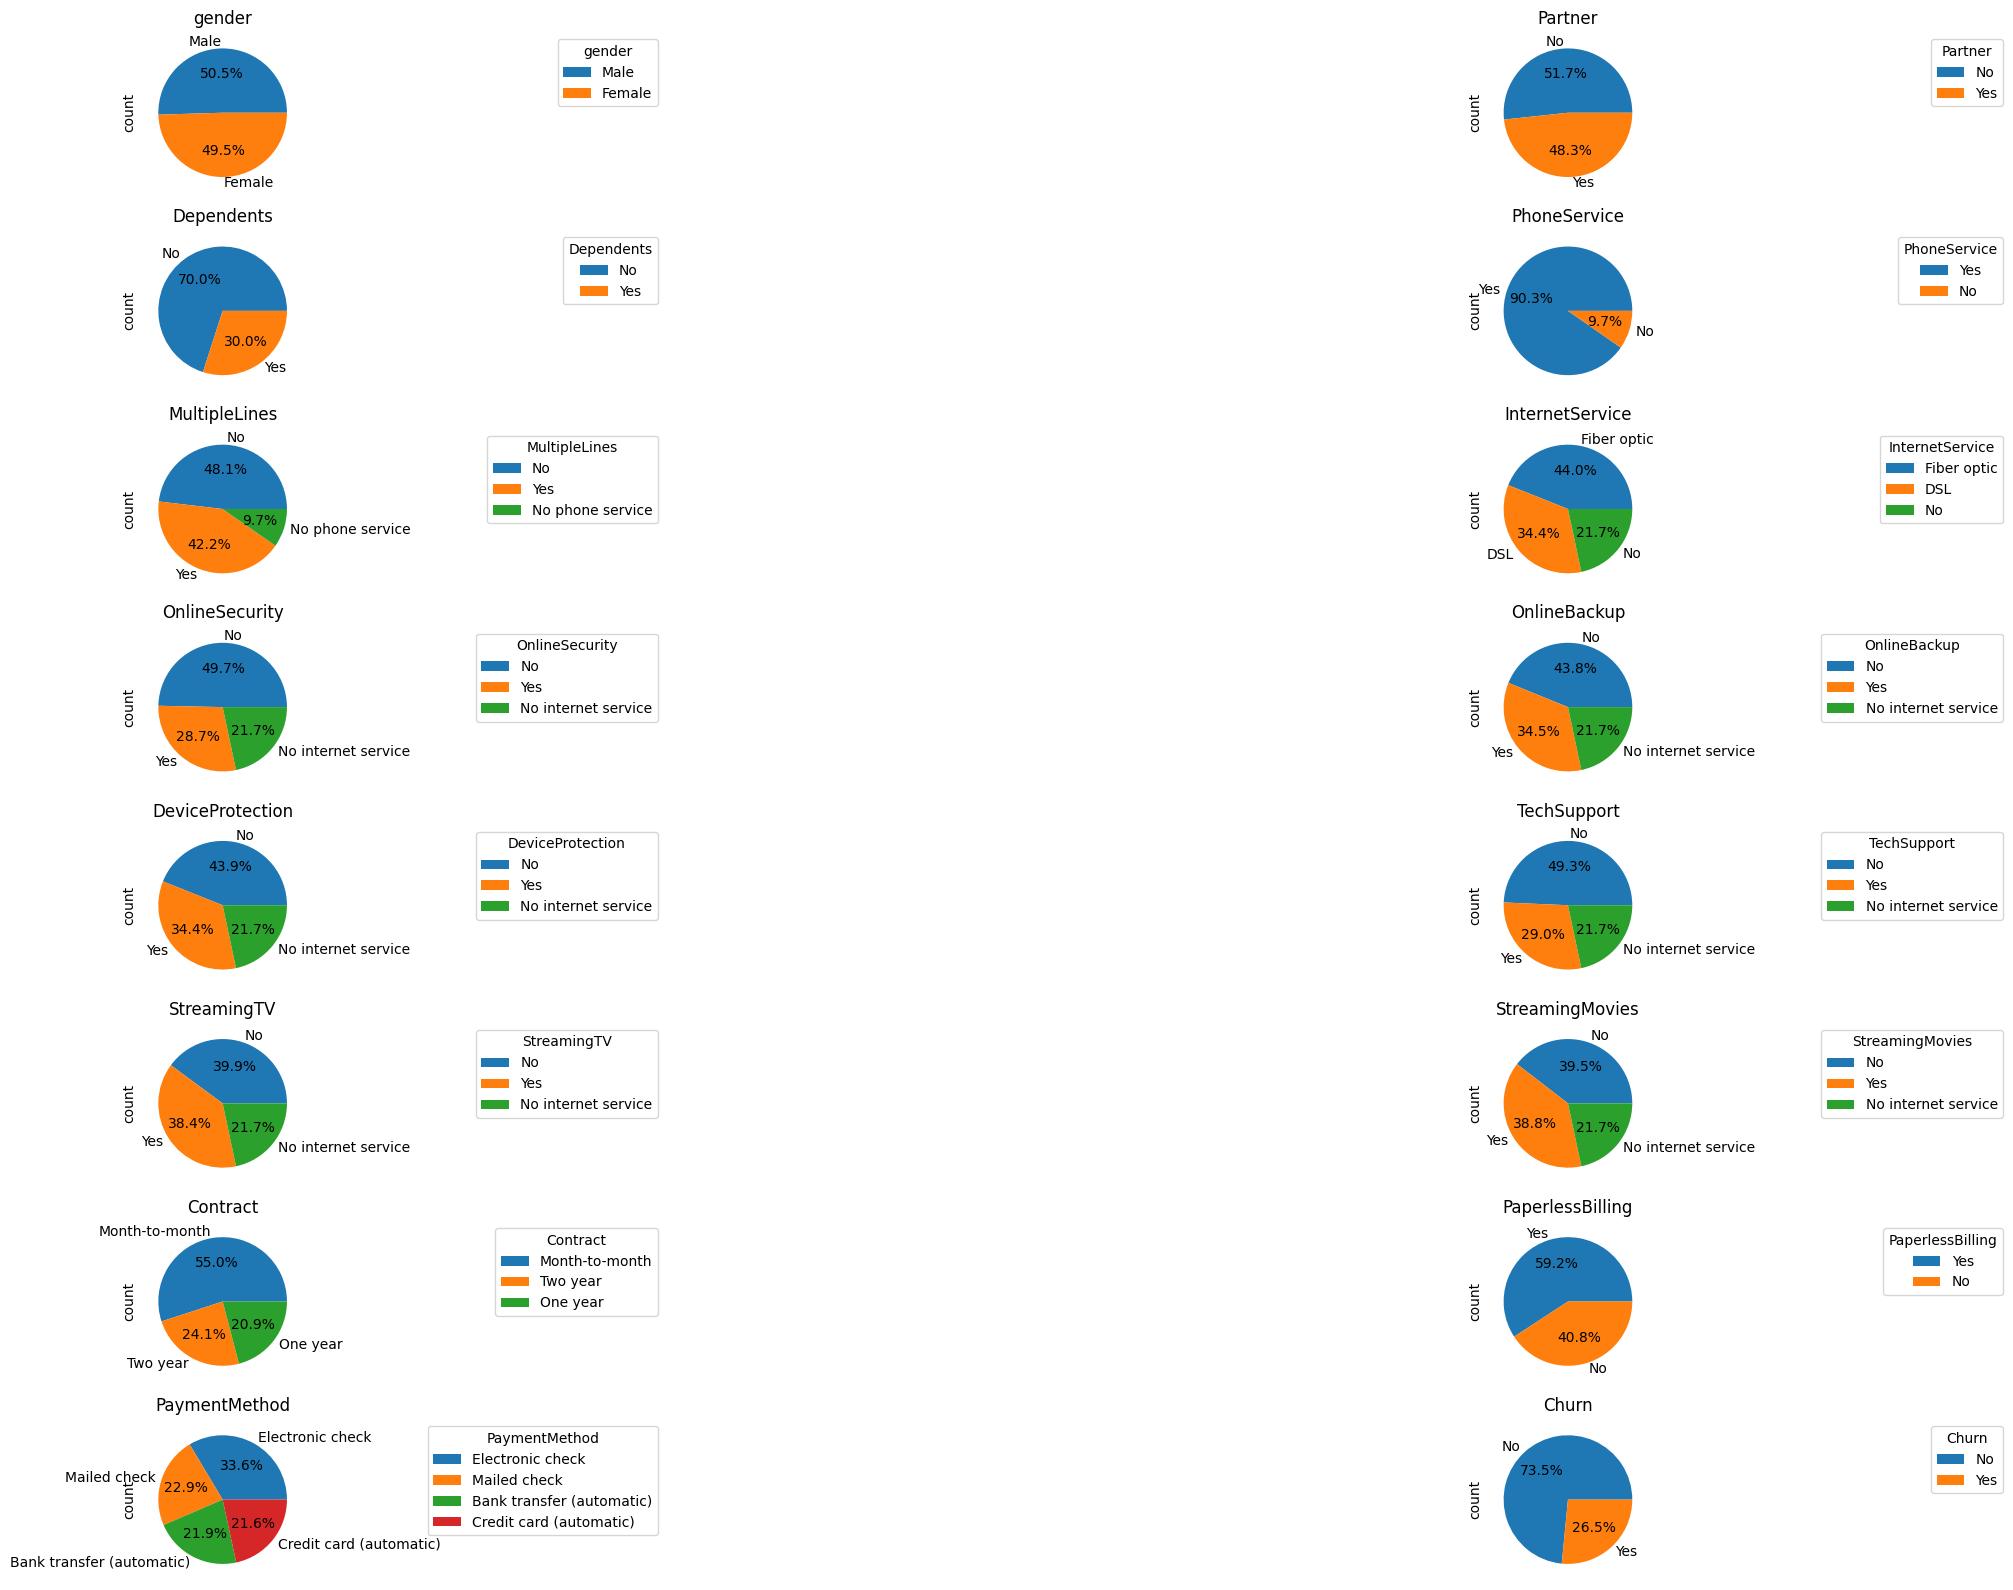

In [248]:
#C.Create a function that will accept a DataFrame as input and return pie-charts for all the appropriate Categorical features. Clearly show percentage distribution in the pie-chart
def plot_categorical_pie_charts(df, figsize=(35, 16)):
  categorical_features = df.select_dtypes(include=['object', 'category']).columns
  fig, axes = plt.subplots(nrows=len(categorical_features) // 2, ncols=2, figsize=figsize)
  for i in range(len(axes.flat)):
    if i >= len(categorical_features):
      break
    ax = axes.flat[i]
    df[categorical_features[i]].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax, legend=True,  title=categorical_features[i])
    legend = ax.legend(title=categorical_features[i])
    legend.set_bbox_to_anchor((3.25, 1))
    ax.set_aspect('equal')
    if len(categorical_features) < len(axes.flat):
      for i in range(len(categorical_features), len(axes.flat)):
        axes.flat[i].axis('off')
  fig.tight_layout()
  plt.show()

plot_categorical_pie_charts(combined_df.drop(['customerID'], axis=1))

D.Share insights for Q2.c.

1.Gender is almost egualy distributed for Male-50.5 and Female-49.5.

2.Partner is almost egualy distributed for No-51.7 and Yes-48.3.

3.70% has No Dependents as compare to 30% has dependents

4.PhoneService is availble to 90.3% as compare 9.7 does not have.

5.48.1% have MultipleLines and 9,7% have no phone service.

6.Maximum 44% have fiber optic InternetService and 21.7% does not have any.

7.49.7% does not have OnlineSecurity.

8.48.3% does not have OnlineBackup.

9.43.9% does not have DeviceProtection.

10.49.3% does not have TechSupport.

11.39.9% does not have StreamingTV.

12.39.5% does not have StreamingMovies.

13.Maximum Contract type is month-to-month and it is 55%.

14.PaperlessBilling is 59.2%

15.Electric check PaymentMethod is maximum with 33.6%.

16.73.5% has no Churn.

In [249]:
#E.Encode all the appropriate Categorical features with the best suitable approach
df = combined_df
categorical_features = np.array(['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']).reshape(-1,1)
encoder = OneHotEncoder(sparse=False)
categorical_features = categorical_features.ravel()
encoder.fit(df[categorical_features])
encoded_df = pd.concat([df.drop(categorical_features, axis=1),
                         pd.DataFrame(encoder.transform(df[categorical_features]))], axis=1)
encoded_df.columns = [col for col in df.columns if col not in categorical_features] + [f"{col}" for col in encoder.get_feature_names_out(categorical_features)]
combined_df = encoded_df
combined_df.head()

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1.0,29.85,29.85,No,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,5575-GNVDE,0,34.0,56.95,1889.50,No,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,3668-QPYBK,0,2.0,53.85,108.15,Yes,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,7795-CFOCW,0,45.0,42.30,1840.75,No,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,9237-HQITU,0,2.0,70.70,151.65,Yes,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [250]:
#F.Split the data into 80% train and 20% test
X = combined_df.drop(['Churn','customerID'], axis=1).values
y = combined_df['Churn'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [251]:
#G.Normalize/Standardize the data with the best suitable approach
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.fit_transform(X_test)

#Q3. Model building and performance improvement

In [252]:
#A.Train a model using Decision tree and check the performance of the model on train and test data
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)
dtree_yhat = dtree.predict(X_test)
dtree_train_acc = accuracy_score(y_train, dtree.predict(X_train))
print('Decision Tree Train Accuracy: ', dtree_train_acc)
dtree_test_acc = accuracy_score(y_test, dtree_yhat)
print('Decision Tree Test Accuracy: ', dtree_test_acc)

Decision Tree Train Accuracy:  0.9985800496982605
Decision Tree Test Accuracy:  0.7068843151171044


In [253]:
#B.Use grid search and improve the performance of the Decision tree model , check the performance of the model on train and test data , provide the differences observed in performance in Q3.a and Q3.b
param_grid_dt = {
    'max_depth': [3, 5, 8],
    'min_samples_split': [2, 5, 10]
}
dt_clf = DecisionTreeClassifier()
grid_dt = GridSearchCV(dt_clf, param_grid_dt, cv=5)
grid_dt.fit(X_train, y_train)
# Best estimator (model with best hyperparameters)
best_dt = grid_dt.best_estimator_
print(best_dt)
# Best score achieved by the best estimator during grid search
best_dt_score = grid_dt.best_score_
print(best_dt_score)

DecisionTreeClassifier(max_depth=5)
0.7866529761182409


In [254]:
dtree_ht = DecisionTreeClassifier(max_depth=grid_dt.best_estimator_.max_depth, min_samples_split=grid_dt.best_estimator_.min_samples_split)
dtree_ht.fit(X_train, y_train)
dtree_ht_yhat = dtree_ht.predict(X_test)
dtree_ht_train_acc = accuracy_score(y_train, dtree_ht.predict(X_train))
print('Decision Tree Train Accuracy after hyperparameter tunning : ', dtree_ht_train_acc)
dtree_ht_test_acc = accuracy_score(y_test, dtree_ht_yhat)
print('Decision Tree Test Accuracy after hyperparameter tunning : ', dtree_ht_test_acc)

Decision Tree Train Accuracy after hyperparameter tunning :  0.7997870074547391
Decision Tree Test Accuracy after hyperparameter tunning :  0.8019872249822569


In [255]:
print("Decision Tree Train Accuracy after hyperparameters tuning : ", round(float(dtree_ht_train_acc)-float(dtree_train_acc), 2)*100,'% means initial model was overfit on training data')
print("Decision Tree Test Accuracy after hyperparameters tuning : ", round(float(dtree_ht_test_acc)-float(dtree_test_acc), 2)*100,'% improvement')

Decision Tree Train Accuracy after hyperparameters tuning :  -20.0 % means initial model was overfit on training data
Decision Tree Test Accuracy after hyperparameters tuning :  10.0 % improvement


In [256]:
#C.Train a model using Random forest and check the performance of the model on train and test data
randomf = RandomForestClassifier()
randomf.fit(X_train, y_train)
randomf_yhat = randomf.predict(X_test)
randomf_train_acc = accuracy_score(y_train, randomf.predict(X_train))
print('Random Forest Train Accuracy: ', randomf_train_acc)
randomf_test_acc = accuracy_score(y_test, randomf_yhat)
print('Random Forest Test Accuracy: ', randomf_test_acc)

Random Forest Train Accuracy:  0.9985800496982605
Random Forest Test Accuracy:  0.7920511000709723


In [257]:
#D. Use grid search and improve the performance of the Random tree model , check the performance of the model on train and test data , provide the differences observed in performance in Q3.c and Q3.d
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 8]
}
rf_clf = RandomForestClassifier()
grid_rf = GridSearchCV(rf_clf, param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print(best_rf)
best_rf_score = grid_rf.best_score_
print(best_rf_score)


RandomForestClassifier(max_depth=8)
0.8015623300830101


In [258]:
randomf_ht = RandomForestClassifier(n_estimators=grid_rf.best_estimator_.n_estimators, max_depth=grid_rf.best_estimator_.max_depth)
randomf_ht.fit(X_train, y_train)
randomf_ht_yhat = randomf_ht.predict(X_test)
randomf_ht_train_acc = accuracy_score(y_train, randomf_ht.predict(X_train))
print('Random Forest Train Accuracy after hyperparameter tunning : ', randomf_ht_train_acc)
randomf_ht_test_acc = accuracy_score(y_test, randomf_ht_yhat)
print('Random Forest Test Accuracy after hyperparameter tunning : ', randomf_ht_test_acc)

Random Forest Train Accuracy after hyperparameter tunning :  0.8315583954561591
Random Forest Test Accuracy after hyperparameter tunning :  0.8048261178140526


In [259]:
print("Random Forest Train Accuracy after hyperparameters tuning : ", round(float(randomf_ht_train_acc)-float(randomf_train_acc), 2)*100,'% means initial model was overfit on training data')
print("Random Forest Test Accuracy after hyperparameters tuning : ", round(float(randomf_ht_test_acc)-float(randomf_test_acc), 2)*100,'% improvement')

Random Forest Train Accuracy after hyperparameters tuning :  -17.0 % means initial model was overfit on training data
Random Forest Test Accuracy after hyperparameters tuning :  1.0 % improvement


In [260]:
#E.Train a model using Adaboost and check the performance of the model on train and test data
adaboost = AdaBoostClassifier()
adaboost.fit(X_train, y_train)
adaboost_yhat = adaboost.predict(X_test)
adaboost_train_acc = accuracy_score(y_train, adaboost.predict(X_train))
print('Adaboost Train Accuracy: ', adaboost_train_acc)
adaboost_test_acc = accuracy_score(y_test, adaboost_yhat)
print('Adaboost Test Accuracy: ', adaboost_test_acc)

Adaboost Train Accuracy:  0.8081292154774583
Adaboost Test Accuracy:  0.8076650106458482


In [261]:
#F. Use grid search and improve the performance of the Adaboost model , check the performance of the model on train and test data , provide the differences observed in performance in Q3.e and Q3.
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0]
}
ada_clf = AdaBoostClassifier()
grid_ada = GridSearchCV(ada_clf, param_grid_ada, cv=5)
grid_ada.fit(X_train, y_train)

best_ada = grid_ada.best_estimator_
print(best_ada)
best_ada_score = grid_ada.best_score_
print(best_ada_score)

AdaBoostClassifier(learning_rate=0.5, n_estimators=100)
0.8029821860012829


In [262]:
adaboost_ht = AdaBoostClassifier(n_estimators=grid_ada.best_estimator_.n_estimators, learning_rate=grid_ada.best_estimator_.learning_rate)
adaboost_ht.fit(X_train, y_train)
adaboost_ht_yhat = adaboost_ht.predict(X_test)
adaboost_ht_train_acc = accuracy_score(y_train, adaboost_ht.predict(X_train))
print('Adaboost Train Accuracy after hyperparameter tunning : ', adaboost_ht_train_acc)
adaboost_ht_test_acc = accuracy_score(y_test, adaboost_ht_yhat)
print('Adaboost Test Accuracy after hyperparameter tunning : ', adaboost_ht_test_acc)

Adaboost Train Accuracy after hyperparameter tunning :  0.8079517216897408
Adaboost Test Accuracy after hyperparameter tunning :  0.8090844570617459


In [263]:
print("Adaboost Train Accuracy after hyperparameters tuning : ", round(float(adaboost_ht_train_acc)-float(adaboost_train_acc), 2)*100,'% improvement')
print("Adaboost Test Accuracy after hyperparameters tuning : ", round(float(adaboost_ht_test_acc)-float(adaboost_test_acc), 2)*100,'% improvement')

Adaboost Train Accuracy after hyperparameters tuning :  -0.0 % improvement
Adaboost Test Accuracy after hyperparameters tuning :  0.0 % improvement


In [264]:
#G.Train a model using GradientBoost and check the performance of the model on train and test data
grboost = GradientBoostingClassifier()
grboost.fit(X_train, y_train)
grboost_yhat = grboost.predict(X_test)
grboost_train_acc = accuracy_score(y_train, grboost.predict(X_train))
print('Gradient Boost Train Accuracy: ', grboost_train_acc)
grboost_test_acc = accuracy_score(y_test, grboost_yhat)
print('Gradient Boost Test Accuracy: ', grboost_test_acc)

Gradient Boost Train Accuracy:  0.8267660631877884
Gradient Boost Test Accuracy:  0.8090844570617459


In [265]:
#H.Use grid search and improve the performance of the GradientBoost model , check the performance of the model on train and test data , provide the differences observed in performance in Q3.g and Q3.h
param_grid_gbr = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.5, 1.0],
    'max_depth': [3, 5, 8]
}
gbr_clf = GradientBoostingClassifier()
grid_gbr = GridSearchCV(gbr_clf, param_grid_gbr, cv=5)
grid_gbr.fit(X_train, y_train)

best_gbr = grid_gbr.best_estimator_
print(best_gbr)
best_gbr_score = grid_gbr.best_score_
print(best_gbr_score)

GradientBoostingClassifier()
0.8001407405189275


In [266]:
grboost_ht = GradientBoostingClassifier(n_estimators=grid_gbr.best_estimator_.n_estimators, learning_rate=grid_gbr.best_estimator_.learning_rate, max_depth=grid_gbr.best_estimator_.max_depth)
grboost_ht.fit(X_train, y_train)
grboost_ht_yhat = grboost_ht.predict(X_test)
grboost_ht_train_acc = accuracy_score(y_train, grboost_ht.predict(X_train))
print('Gradient Boost Train Accuracy after hyperparameter tunning : ', grboost_ht_train_acc)
grboost_ht_test_acc = accuracy_score(y_test, grboost_ht_yhat)
print('Gradient Boost Test Accuracy after hyperparameter tunning : ', grboost_ht_test_acc)

Gradient Boost Train Accuracy after hyperparameter tunning :  0.8267660631877884
Gradient Boost Test Accuracy after hyperparameter tunning :  0.8090844570617459


In [267]:
print("Gradient Boost Train Accuracy after hyperparameters tuning : ", round(float(grboost_ht_train_acc)-float(grboost_train_acc), 2)*100,'% improvement')
print("Gradient Boost Test Accuracy after hyperparameters tuning : ", round(float(grboost_ht_test_acc)-float(grboost_test_acc), 2)*100,'% improvement')

Gradient Boost Train Accuracy after hyperparameters tuning :  0.0 % improvement
Gradient Boost Test Accuracy after hyperparameters tuning :  0.0 % improvement


In [268]:
#I. Provide detailed analysis of the below steps
#(1) Compare the performance of each model in train stage and test stage
pd.DataFrame({'Method':['Decision Tree', 'Random Forest', 'Adaboost', 'Gradient Boost'],
              'Train Accuracy': [dtree_train_acc, randomf_train_acc, adaboost_train_acc, grboost_train_acc],
              'After Tuning Train Accuracy': [dtree_ht_train_acc, randomf_ht_train_acc, adaboost_ht_train_acc, grboost_ht_train_acc],
              'Test Accuracy': [dtree_test_acc, randomf_test_acc, adaboost_test_acc, grboost_test_acc],
              'After Tuning Test Accuracy': [dtree_ht_test_acc, randomf_ht_test_acc, adaboost_ht_test_acc, grboost_ht_test_acc]})

,Method,Train Accuracy,After Tuning Train Accuracy,Test Accuracy,After Tuning Test Accuracy
0,Decision Tree,0.998580,0.799787,0.706884,0.801987
1,Random Forest,0.998580,0.831558,0.792051,0.804826
2,Adaboost,0.808129,0.807952,0.807665,0.809084
3,Gradient Boost,0.826766,0.826766,0.809084,0.809084


In [269]:
#(2) Provide your observation on which model performed the best
print('Gradient Boost model performed the best')

Gradient Boost model performed the best


In [270]:
#(3) Provide your reasoning on why the model performed best
print('Gradient Boosting often performs better due to its sequential learning process that focuses on correcting previous errors','\n','flexibility in optimizing various loss functions, built-in regularization techniques to prevent overfitting, and its ability to handle complex data structures')

Gradient Boosting often performs better due to its sequential learning process that focuses on correcting previous errors 
 flexibility in optimizing various loss functions, built-in regularization techniques to prevent overfitting, and its ability to handle complex data structures


In [271]:
#(4) Provide your final conclusion on your observation
print('Hyperparameter tuning improved the performance of Decision Tree and Random Forest but not for Adaboost and Gradient Boost')
print('Adaboost and Gradient Boost performed better as compare to Decision Tree and Random Forest')

Hyperparameter tuning improved the performance of Decision Tree and Random Forest but not for Adaboost and Gradient Boost
Adaboost and Gradient Boost performed better as compare to Decision Tree and Random Forest
